In [2]:
import sys
from pathlib import Path

TASK_DIR = Path("/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-SOG-Ji/fit-electrolyte-180").resolve()
ROOT_DIR = TASK_DIR.parent  # .../CACE-SOG-Qeq（含 cace 包）
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from ase.io import read
import cace
import torch
import numpy as np
from torch import nn
from cace.tools.scatter import scatter_sum
from cace.tools import torch_geometric
from cace.data.atomic_data import AtomicData


MODEL_PATH = TASK_DIR / "loss_data"/ "SOG_MP1_min_mae_e20260417_005245_model.pth"
DATA_PATH = TASK_DIR / "electrolyte_180.xyz"
print("ROOT_DIR:", ROOT_DIR)
print("model:", MODEL_PATH)
print("data:", DATA_PATH)

model = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
model.eval()

# 保留 ASE 数据（仅用于某些可视化/兼容）
data = read(str(DATA_PATH), ":")

# 关键修正：评估必须走带 charge 的数据管线，避免 EvaluateTask(list[Atoms]) 丢失 charge
z_map = {"H": 1, "O": 8, "F": 9, "K": 19}
# 该数据集使用 extxyz header 的总能量，不做 atomic_energies 扣除
atomic_energies = None
cutoff = float(model.models[0].representation.cutoff) if hasattr(model, "models") else float(model.representation.cutoff)

def build_atomicdata_with_charge_simple(xyz_path, cutoff):
    """极简版：直接从 extxyz 读 ASE Atoms，再转 AtomicData；自动兼容 `charge` 或 `q` 列。"""
    atoms_list = read(str(xyz_path), ":")
    dataset = []
    for at in atoms_list:
        if "charge" in at.arrays:
            charge_key = "charge"
        elif "q" in at.arrays:
            charge_key = "q"
        else:
            raise KeyError("extxyz 缺少每原子电荷列（charge 或 q），无法直接评估含电荷模型")

        d = AtomicData.from_atoms(
            atoms=at,
            cutoff=cutoff,
            # 把 extxyz 里的电荷列映射为模型会读取的键 `charge`
            data_key={"charge": charge_key},
            atomic_energies=None,
        )
        dataset.append(d)
    return dataset



data_with_charge = build_atomicdata_with_charge_simple(DATA_PATH, cutoff)
print("num structures (with charge):", len(data_with_charge))



ROOT_DIR: /data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-SOG-Ji
model: /data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-SOG-Ji/fit-electrolyte-180/loss_data/SOG_MP1_min_mae_e20260417_005245_model.pth
data: /data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-SOG-Ji/fit-electrolyte-180/electrolyte_180.xyz
num structures (with charge): 180


In [3]:
import numpy as np

def load_ref_energy_forces_from_extxyz(path, atomic_energies, z_map):
    energies, atom_nums, forces_blocks = [], [], []
    with open(path, "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            line = line.strip()
            if not line:
                continue
            nat = int(line)
            header = f.readline().strip()
            energy = None
            if "energy=" in header:
                try:
                    e_str = header.split("energy=")[1].split()[0]
                    energy = float(e_str)
                except Exception:
                    energy = None
            species, fl = [], []
            for _ in range(nat):
                parts = f.readline().split()
                species.append(parts[0])
                vals = [float(x) for x in parts[1:]]
                if len(vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                fl.append(vals[3:6])
            Z = [z_map[s] for s in species]
            if energy is not None and atomic_energies is not None:
                energy -= sum(atomic_energies.get(int(z), 0.0) for z in Z)
            if energy is None:
                raise ValueError("no energy= in frame header")
            energies.append(energy)
            atom_nums.append(nat)
            forces_blocks.append(np.asarray(fl, dtype=np.float64))
    ref_energy = np.asarray(energies, dtype=np.float64)
    atom_num = np.asarray(atom_nums, dtype=np.float64)
    ref_force = np.concatenate(forces_blocks, axis=0)
    return ref_energy, atom_num, ref_force

In [4]:
# 与 cell0 中保持一致
z_map = {"H": 1, "O": 8, "F": 9, "K": 19}
atomic_energies = {
    1: -0.1749365806299343,
    8: -0.08746829031496617,
    9: -4.620975436064299,
    19: -4.620975436064285,
}
ref_energy, atom_num, ref_force = load_ref_energy_forces_from_extxyz(
    str(DATA_PATH), atomic_energies, z_map
)

In [5]:
def evaluate_model_on_atomicdata(model, dataset, batch_size=8, device="cpu"):
    loader = torch_geometric.dataloader.DataLoader(
        dataset, batch_size=batch_size, shuffle=False, drop_last=False
    )
    energies, forces = [], []
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)
        out = model(d, training=False)
        if "CACE_energy" not in out or "CACE_forces" not in out:
            raise KeyError(f"missing keys in model output: {list(out.keys())}")
        energies.append(out["CACE_energy"].detach().cpu().numpy().reshape(-1))
        forces.append(out["CACE_forces"].detach().cpu().numpy())
    return {
        "energy": np.concatenate(energies, axis=0),
        "forces": np.concatenate(forces, axis=0),
    }

In [6]:
pre = evaluate_model_on_atomicdata(model, data_with_charge, batch_size=8, device="cpu")
pre["energy"]

array([-0.5154371 , -0.82678413, -0.8753805 , -0.62760544,  0.2696762 ,
       -1.143858  , -0.726284  , -0.7884531 , -0.3596449 , -1.3906441 ,
       -0.5042076 , -1.3146992 , -0.22130775, -0.90063095, -0.86126137,
       -1.2735462 , -1.3874912 , -1.5458183 , -1.5604572 , -0.22137833,
       -0.2901659 ,  0.18805122, -1.6429634 , -1.5449581 , -0.93231773,
       -1.2701845 ,  0.41483116, -0.9337473 ,  1.0259333 , -0.56226635,
       -1.249773  , -0.28360176, -0.5092468 ,  0.03053474, -0.6396227 ,
       -1.0963774 , -1.7599363 , -0.35625648, -1.4681826 , -0.59999466,
       -0.7206526 , -1.424943  , -1.5197363 ,  0.7158346 , -0.49473858,
       -1.0579987 , -0.44459724, -0.5738611 ,  0.5434027 , -0.23731613,
       -0.97194576, -1.1529408 , -1.0508146 ,  0.6828432 , -0.41498184,
       -0.8085594 , -0.16770554, -0.8594198 , -1.1895819 , -0.28156853,
       -0.6382055 ,  0.06587791, -2.5060062 , -0.9573746 ,  0.6181793 ,
       -1.6844788 , -1.2958183 , -0.68786526, -0.8731222 , -1.19

In [7]:
ref_energy

array([-0.52562102, -0.84365692, -0.83960349, -0.61657235,  0.22976888,
       -1.1350692 , -0.71884254, -0.80137597, -0.36980447, -1.38170617,
       -0.50036038, -1.31818067, -0.2195828 , -0.92702165, -0.86378508,
       -1.30644457, -1.41015569, -1.5651034 , -1.56239076, -0.22205675,
       -0.30599663,  0.18189618, -1.67036517, -1.53791132, -0.93423644,
       -1.28867042,  0.4134538 , -0.94906018,  1.02448877, -0.56809722,
       -1.25505995, -0.29178334, -0.51141113,  0.03609321, -0.64829005,
       -1.10443798, -1.75717588, -0.36564826, -1.48819391, -0.62085939,
       -0.7261884 , -1.43065964, -1.50331736,  0.70990094, -0.50601162,
       -1.05244076, -0.45084865, -0.58636572,  0.54157877, -0.24713355,
       -0.95502742, -1.1537623 , -1.04664193,  0.68450314, -0.43291235,
       -0.81778172, -0.16495589, -0.85632633, -1.19032247, -0.28729292,
       -0.65416348,  0.05848442, -2.52157392, -0.97910717,  0.60565976,
       -1.68667859, -1.29923262, -0.70433524, -0.88338301, -1.21

In [8]:
np.sqrt(np.mean(((ref_energy-pre['energy'])/atom_num)**2))

np.float64(6.803591220083255e-05)

In [9]:
pre["forces"]

array([[ 0.07720532,  2.0784516 ,  0.04058039],
       [-0.39464474, -0.8221601 , -0.43453178],
       [-0.31218803, -0.33154273,  0.2005114 ],
       ...,
       [-0.16358384,  0.50777954,  0.6186037 ],
       [-0.17610377, -0.27280837, -0.40189564],
       [-0.23879418, -0.68735534,  0.8323463 ]],
      shape=(35280, 3), dtype=float32)

In [10]:
ref_force

array([[ 0.09020354,  2.06646389,  0.04861393],
       [-0.39019317, -0.82554405, -0.43619726],
       [-0.31231601, -0.33263581,  0.20111582],
       ...,
       [-0.15969228,  0.50565131,  0.61035704],
       [-0.17494676, -0.2723034 , -0.39950863],
       [-0.23634409, -0.6830891 ,  0.82585624]], shape=(35280, 3))

In [11]:
# ref_force shape: (N_total_atoms, 3)

In [12]:
np.sqrt(np.mean((ref_force-pre['forces'])**2))

np.float64(0.005294943850933829)

cor: 2.7897134771764622
q MAE (scaled+cor): 0.002973530168949612
q RMSE(scaled+cor): 0.0044744805729346


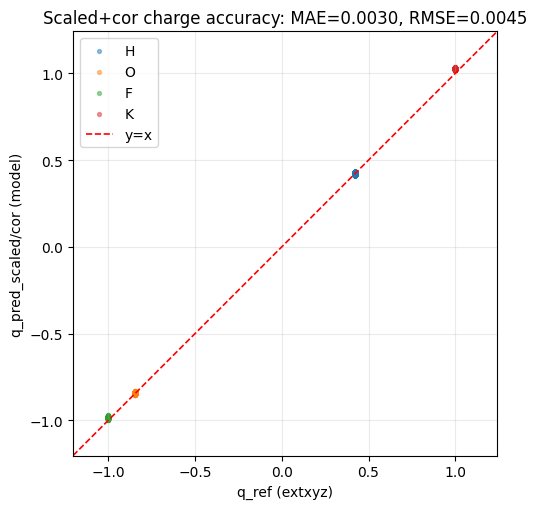

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 电荷作图（加入 cor 标定）
# 依赖：q_ref, elem_Z，以及 q_pred 或 q_pred_scaled

# 1) 准备 scaled_raw 预测电荷
if "q_pred" in globals():
    charge_eq_mod = None
    if "model" in globals():
        for m in model.modules():
            if m.__class__.__name__ == "ChargeEq":
                charge_eq_mod = m
                break
    if charge_eq_mod is not None and hasattr(charge_eq_mod, "normalization_factor"):
        nf = float(charge_eq_mod.normalization_factor)
        q_pred_scaled_raw = q_pred * nf
    else:
        q_pred_scaled_raw = q_pred.copy()
else:
    if "q_pred_scaled" in globals():
        q_pred_scaled_raw = q_pred_scaled.copy()
    else:
        # 自动提取 q_pred（参考 fit-SOG-testq 的做法）
        if "model" not in globals() or "data_with_charge" not in globals():
            raise NameError("缺少 q_pred/q_pred_scaled，且找不到 model + data_with_charge 用于自动提取")

        _dev = device if "device" in globals() else "cpu"
        _loader = torch_geometric.dataloader.DataLoader(
            data_with_charge, batch_size=8, shuffle=False, drop_last=False
        )
        _q_all = []
        model.eval()
        for _batch in _loader:
            _batch = _batch.to(_dev)
            _d = _batch.to_dict()
            _d["positions"] = _d["positions"].detach().requires_grad_(True)
            _out = model(_d, training=False)
            if "q_eq" in _out:
                _q_all.append(_out["q_eq"].detach().cpu().numpy().reshape(-1))
            elif "q" in _out:
                _q_all.append(_out["q"].detach().cpu().numpy().reshape(-1))
            else:
                raise KeyError(f"model output keys have no 'q_eq' or 'q': {list(_out.keys())}")
        q_pred = np.concatenate(_q_all, axis=0)

        # 再按 normalization_factor 转成 scaled_raw
        _charge_eq_mod = None
        for _m in model.modules():
            if _m.__class__.__name__ == "ChargeEq":
                _charge_eq_mod = _m
                break
        if _charge_eq_mod is not None and hasattr(_charge_eq_mod, "normalization_factor"):
            _nf = float(_charge_eq_mod.normalization_factor)
            q_pred_scaled_raw = q_pred * _nf
        else:
            q_pred_scaled_raw = q_pred.copy()

# 若 q_ref 不存在：从 extxyz 读取参考电荷（最后一列）
if "q_ref" not in globals():
    if "DATA_PATH" not in globals():
        raise NameError("缺少 q_ref 且找不到 DATA_PATH，无法读取参考电荷")

    _q_blocks = []
    with open(str(DATA_PATH), "r") as _f:
        while True:
            _line = _f.readline()
            if not _line:
                break
            _line = _line.strip()
            if not _line:
                continue
            _nat = int(_line)
            _ = _f.readline()  # header
            _q_now = []
            for _i in range(_nat):
                _parts = _f.readline().split()
                _vals = [float(_x) for _x in _parts[1:]]
                if len(_vals) < 7:
                    raise ValueError("expect pos[3], forces[3], charge[1] per line")
                _q_now.append(_vals[6])
            _q_blocks.append(np.asarray(_q_now, dtype=np.float64))
    q_ref = np.concatenate(_q_blocks, axis=0)

# 2) cor = (q_ref · q_pred_scaled_raw) / (q_ref · q_ref)
den = float(np.dot(q_ref.flatten(), q_ref.flatten()))
if den <= 1e-20:
    raise ValueError("q_ref 范数过小，无法计算 cor")
cor = float(np.dot(q_ref.flatten(), q_pred_scaled_raw.flatten()) / den)
if abs(cor) <= 1e-20:
    raise ValueError("cor 过小，无法做 pred/cor 标定")

q_pred_scaled = q_pred_scaled_raw / cor
mae_scaled = float(np.mean(np.abs(q_ref - q_pred_scaled)))
rmse_scaled = float(np.sqrt(np.mean((q_ref - q_pred_scaled) ** 2)))

print("cor:", cor)
print("q MAE (scaled+cor):", mae_scaled)
print("q RMSE(scaled+cor):", rmse_scaled)

# 3) 散点图：x=真实, y=预测，并画 y=x
z_to_symbol = {1: "H", 8: "O", 9: "F", 19: "K", 11: "Na", 17: "Cl"}
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

# 若 elem_Z 不存在：从 data_with_charge 中提取原子序号
if "elem_Z" not in globals():
    if "data_with_charge" not in globals():
        raise NameError("缺少 elem_Z 且找不到 data_with_charge")
    elem_Z = np.concatenate([
        d.atomic_numbers.detach().cpu().numpy().reshape(-1)
        if hasattr(d.atomic_numbers, "detach")
        else np.asarray(d.atomic_numbers).reshape(-1)
        for d in data_with_charge
    ]).astype(int)

plt.close("all")
fig, ax = plt.subplots(figsize=(5.2, 5.2))

for i, z in enumerate(sorted(np.unique(elem_Z))):
    mask = (elem_Z == z)
    if not np.any(mask):
        continue
    label = z_to_symbol.get(int(z), f"Z={int(z)}")
    ax.scatter(
        q_ref[mask],
        q_pred_scaled[mask],
        s=8,
        alpha=0.45,
        c=colors[i % len(colors)],
        label=label,
    )

xy_min = float(min(np.min(q_ref), np.min(q_pred_scaled)))
xy_max = float(max(np.max(q_ref), np.max(q_pred_scaled)))
pad = 0.10 * max(1e-8, (xy_max - xy_min))
lo, hi = xy_min - pad, xy_max + pad

ax.plot([lo, hi], [lo, hi], "r--", lw=1.2, label="y=x")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("q_ref (extxyz)")
ax.set_ylabel("q_pred_scaled/cor (model)")
ax.set_title(f"Scaled+cor charge accuracy: MAE={mae_scaled:.4f}, RMSE={rmse_scaled:.4f}")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()


In [14]:
# 诊断：输出原始 q_pred / q_ref，并计算原始 q_pred vs q_ref 的线性回归参数
import numpy as np

if "q_ref" not in globals() or "q_pred" not in globals():
    raise NameError("请先运行电荷提取相关 cell，确保 q_ref 与 q_pred 已存在")

q_ref_arr = np.asarray(q_ref).reshape(-1)
q_pred_arr = np.asarray(q_pred).reshape(-1)

print(f"len(q_ref)={len(q_ref_arr)}, len(q_pred)={len(q_pred_arr)}")
if len(q_ref_arr) != len(q_pred_arr):
    raise ValueError("q_ref 与 q_pred 长度不一致，无法做线性回归")

print("q_ref[:20] =", q_ref_arr[:20])
print("q_pred_raw[:20] =", q_pred_arr[:20])

# 线性回归：q_pred = slope * q_ref + intercept
# 使用最小二乘闭式解（避免额外依赖）
x = q_ref_arr
y = q_pred_arr
x_mean = float(np.mean(x))
y_mean = float(np.mean(y))
var_x = float(np.mean((x - x_mean) ** 2))
if var_x <= 1e-20:
    raise ValueError("q_ref 方差过小，无法回归")

cov_xy = float(np.mean((x - x_mean) * (y - y_mean)))
slope = cov_xy / var_x
intercept = y_mean - slope * x_mean

y_fit = slope * x + intercept
ss_res = float(np.sum((y - y_fit) ** 2))
ss_tot = float(np.sum((y - y_mean) ** 2))
r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 1e-20 else float("nan")

print("\n=== Raw q_pred vs q_ref linear regression ===")
print(f"slope     = {slope:.8f}")
print(f"intercept = {intercept:.8f}")
print(f"R^2       = {r2:.8f}")

len(q_ref)=35280, len(q_pred)=35280
q_ref[:20] = [-0.8476  0.4238  0.4238 -0.8476  0.4238  0.4238 -0.8476  0.4238  0.4238
 -0.8476  0.4238  0.4238 -0.8476  0.4238  0.4238 -0.8476  0.4238  0.4238
 -0.8476  0.4238]
q_pred_raw[:20] = [-2.3387747  1.1970347  1.1939783 -2.3642612  1.1790788  1.1974072
 -2.3552847  1.1856494  1.1895372 -2.3601665  1.1886989  1.1872947
 -2.3649511  1.1834301  1.1901363 -2.3594348  1.1873237  1.1787715
 -2.3670788  1.190917 ]

=== Raw q_pred vs q_ref linear regression ===
slope     = 2.78971348
intercept = 0.00669527
R^2       = 0.99996170


In [15]:
from cace.models.combined import CombinePotential
from cace.data.atomic_data import AtomicData
from ase.atoms import Atoms


def evaluate_sr_lr_energies_on_atomicdata(model, dataset, batch_size=8, device="cpu", cutoff=4.5):
    """
    每结构能量：短程 SR + 长程 LR（SOG / ChargeEq）。

    - 支持输入 `AtomicData` 列表，或 `ase.Atoms` 列表。
    - 若输入是 Atoms，会自动转成 AtomicData。
    """
    if len(dataset) == 0:
        raise ValueError("dataset 为空")

    first_item = dataset[0]
    if isinstance(first_item, Atoms):
        dataset = [AtomicData.from_atoms(a, cutoff=cutoff) for a in dataset]

    loader = torch_geometric.dataloader.DataLoader(
        dataset, batch_size=batch_size, shuffle=False, drop_last=False
    )

    def _w(pk):
        w = pk.get("weight", 1.0)
        return float(w.item()) if isinstance(w, torch.Tensor) else float(w)

    e_sr_list, e_lr_list, e_tot_list = [], [], []

    # 不能用 torch.no_grad()：Forces 要对 positions 做 autograd.grad
    for batch in loader:
        batch = batch.to(device)
        d = batch.to_dict()
        d["positions"] = d["positions"].detach().requires_grad_(True)

        if isinstance(model, CombinePotential):
            pk0, pk1 = model.potential_keys[0], model.potential_keys[1]
            k0, k1 = pk0["CACE_energy"], pk1["CACE_energy"]
            out0 = model.models[0](d, training=False)
            out1 = model.models[1](d, training=False)
            t0 = out0[k0].reshape(-1)
            t1 = out1[k1].reshape(-1)
            e_sr_list.append((t0 * _w(pk0)).detach().cpu().numpy())
            e_lr_list.append((t1 * _w(pk1)).detach().cpu().numpy())
            e_tot_list.append((t0 * _w(pk0) + t1 * _w(pk1)).detach().cpu().numpy())
        else:
            out = model(d, training=False)
            if "SR_energy" not in out or "SOG_potential" not in out:
                raise KeyError(
                    "期望键 SR_energy、SOG_potential（单 NNP Qeq）；实际: "
                    + str(sorted(out.keys()))
                )
            e_sr = out["SR_energy"].reshape(-1)
            e_lr = out["SOG_potential"].reshape(-1)
            e_tot = out["CACE_energy"].reshape(-1)
            e_sr_list.append(e_sr.detach().cpu().numpy())
            e_lr_list.append(e_lr.detach().cpu().numpy())
            e_tot_list.append(e_tot.detach().cpu().numpy())

    E_sr = np.concatenate(e_sr_list)
    E_lr = np.concatenate(e_lr_list)
    E_tot = np.concatenate(e_tot_list)
    diff = np.abs(E_tot - (E_sr + E_lr))
    return {
        "SR_energy": E_sr,
        "LR_energy": E_lr,
        "CACE_energy": E_tot,
        "sr_lr_sum": E_sr + E_lr,
        "sr_lr_consistency_max_abs": float(np.max(diff)),
        "sr_lr_consistency_rmse": float(np.sqrt(np.mean(diff**2))),
    }


res = evaluate_sr_lr_energies_on_atomicdata(model, data, batch_size=8, device="cpu", cutoff=4.5)
print("SR (前5个):", res["SR_energy"][:20])
print("LR (前5个):", res["LR_energy"][:20])
print("TOT(前5个):", res["CACE_energy"][:20])
print("max|TOT-(SR+LR)| =", res["sr_lr_consistency_max_abs"])
print("rmse            =", res["sr_lr_consistency_rmse"])


SR (前5个): [-10.167017 -10.485123 -10.606552 -10.090374  -9.212729 -11.379403
 -10.69999  -10.628952  -9.971851 -10.870753  -9.942622 -11.205075
  -9.973822 -10.501763 -10.938734 -10.652647 -10.770193 -10.949763
 -10.874464  -9.686168]
LR (前5个): [ 9.65158   9.658339  9.731172  9.462769  9.482406 10.235545  9.973706
  9.840499  9.612206  9.480109  9.438415  9.890376  9.752514  9.601132
 10.077473  9.379101  9.382702  9.403945  9.314007  9.464789]
TOT(前5个): [-0.5154371  -0.82678413 -0.8753805  -0.62760544  0.2696762  -1.143858
 -0.726284   -0.7884531  -0.3596449  -1.3906441  -0.5042076  -1.3146992
 -0.22130775 -0.90063095 -0.86126137 -1.2735462  -1.3874912  -1.5458183
 -1.5604572  -0.22137833]
max|TOT-(SR+LR)| = 0.0
rmse            = 0.0


=== Gaussian kernel parameters (SOG) ===
shift_1: [-2.97593284 -2.56241488 -2.11770201 -1.61092746 -1.20919549 -0.62899566
 -0.24957772  0.03749035  0.06213348  0.23250766  0.58746272  0.92492425]
amplitude_1: [-7.04541063 11.46126556 -4.96629477  0.43422875  0.20693912 -0.12722775
  0.47426966  2.17531276  4.37844181  9.61364746 22.24196243 64.89162445]


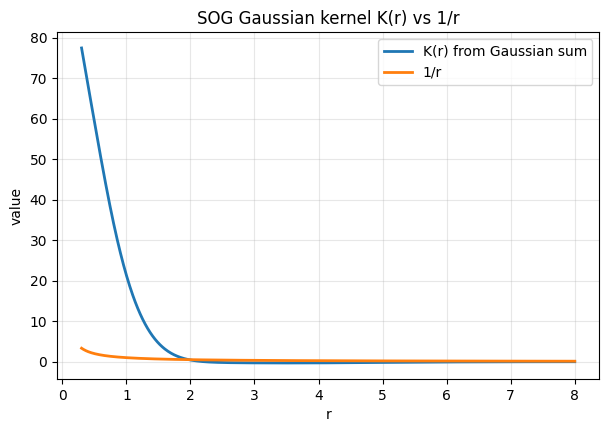

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# 在已加载模型中查找 SOGPotential 模块
sog_mod = None
for m in model.modules():
    if m.__class__.__name__ == "SOGPotential":
        sog_mod = m
        break

if sog_mod is None:
    raise RuntimeError("未在 model 中找到 SOGPotential 模块")

shift = sog_mod.shift_1.detach().cpu().numpy().astype(float)
amp = sog_mod.amplitude_1.detach().cpu().numpy().astype(float)

print("=== Gaussian kernel parameters (SOG) ===")
print("shift_1:", shift)
print("amplitude_1:", amp)

# 按当前 cace/modules/ewald.py 的 real-space 写法重建核函数:
# K(r) = sum_i amplitude_i * exp(-r^2 / shift_i^2)
def K_of_r(r, shift, amp):
    r = np.asarray(r, dtype=float)
    s2 = np.maximum(np.square(shift), 1e-12)
    return np.sum(amp[None, :] * np.exp(-np.square(r)[:, None] / s2[None, :]), axis=1)

r = np.linspace(0.3, 8.0, 800)
K = K_of_r(r, shift, amp)
inv_r = 1.0 / r

plt.figure(figsize=(7, 4.5))
plt.plot(r, K, label="K(r) from Gaussian sum", lw=2)
plt.plot(r, inv_r, label="1/r", lw=2)
plt.xlabel("r")
plt.ylabel("value")
plt.title("SOG Gaussian kernel K(r) vs 1/r")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
